## setup

In [1]:
from moabb.datasets import BNCI2014_001
import moabb.paradigms as mp
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from moabb.evaluations import WithinSessionEvaluation
import random
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import make_pipeline
from functools import partial
from sklearn.pipeline import make_pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from moabb.pipelines.features import LogVariance
import numpy as np


/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
dataset = BNCI2014_001()


## initial exploration

In [3]:
paradigm=mp.MotorImagery(scorer=["accuracy", "balanced_accuracy", "f1_macro"])


Choosing from all possible events


In [5]:
pipeline = make_pipeline(
            FunctionTransformer(add_gaussian_noise),
            CSP(n_components=8),
            LDA()
        )

In [6]:
def add_gaussian_noise(X, noise_level=0.1):
    X = X.copy()

    signal_std = np.std(X)

    noise = np.random.normal(
        0,
        noise_level * signal_std,
        X.shape
    )

    return X + noise

In [6]:
evaluation = WithinSessionEvaluation( #k fold cross validation
    paradigm=paradigm, datasets=[dataset], overwrite=True, hdf5_path=None, 
)

In [ ]:
results = evaluation.process({"csp+lda": pipeline})

Computing rank from data with rank=None
    Using tolerance 62 (2.2e-16 eps * 22 dim * 1.3e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 62 (2.2e-16 eps * 22 dim * 1.3e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 62 (2.2e-16 eps * 22 dim * 1.3e+

In [ ]:
avgRes=[]
avgRes=pd.DataFrame(avgRes)
avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()
avgRes['Balanced Accuracy']=results.groupby('session')['score_balanced_accuracy'].mean()
avgRes['score_f1_macro']=results.groupby('session')['score_f1_macro'].mean()

print(avgRes)

fig, ax = plt.subplots(figsize=(8, 7))
results["subj"] = results["subject"].apply(str)
sns.barplot(
    x="score_accuracy", y="subj", hue="session", data=results, orient="h", palette="viridis", ax=ax
)
plt.show()

## multiple tests

In [14]:
levels=[0.1, 0.2, 0.3, 0.4, 0.5]
num=1

In [8]:
accuracy=[]
for level in levels:
    all_avgs = []

    pipeline = make_pipeline(
            FunctionTransformer(
            partial(add_gaussian_noise, noise_level=level),
            validate=False
        ),
            CSP(n_components=8),
            LDA()
        )


    paradigm = mp.MotorImagery(
        scorer=["accuracy", "balanced_accuracy", "f1_macro"],
    )

    evaluation = WithinSessionEvaluation(
        paradigm=paradigm,
        datasets=[dataset],
        overwrite=True,
        hdf5_path=None
    )

    results = evaluation.process({"csp+lda": pipeline})
    
    avgRes=[]
    avgRes=pd.DataFrame(avgRes)
    avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()

    all_avgs.append(avgRes)

    TestAccuracy=0
    for dset in all_avgs:
        TestAccuracy+=dset.iloc[1]['Accuracy']
    
    accuracy.append(TestAccuracy/num)

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 47 (2.2e-16 eps * 22 dim * 9.7e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 47 (2.2e-16 eps * 22 dim * 9.7e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 47 (2.2e-16 eps * 22 dim * 9.7e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 52 (2.2e-16 eps * 22 dim * 1.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 52 (2.2e-16 eps * 22 dim * 1.1e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 52 (2.2e-16 eps * 22 dim * 1.1e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 59 (2.2e-16 eps * 22 dim * 1.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 60 (2.2e-16 eps * 22 dim * 1.2e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 59 (2.2e-16 eps * 22 dim * 1.2e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(


In [10]:
sum(accuracy)/len(accuracy)

np.float32(0.6935763)

## train only

In [15]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import make_pipeline
from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA


class TrainOnlyGaussianNoiseClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, noise_level=0.1, n_components=8, random_state=None):
        self.noise_level = noise_level
        self.n_components = n_components
        self.random_state = random_state

    def _add_noise(self, X):
        X = X.copy()

        rng = np.random.default_rng(self.random_state)
        signal_std = np.std(X)

        noise = rng.normal(
            loc=0,
            scale=self.noise_level * signal_std,
            size=X.shape
        )

        return X + noise

    def fit(self, X, y):
        X_train_noisy = self._add_noise(X)

        self.clf_ = make_pipeline(
            CSP(n_components=self.n_components),
            LDA()
        )

        self.clf_.fit(X_train_noisy, y)
        return self

    def predict(self, X):
        # test set is NOT noised
        return self.clf_.predict(X)

    def predict_proba(self, X):
        return self.clf_.predict_proba(X)

In [17]:
accuracy=[]
for level in levels:
    all_avgs = []

    paradigm = mp.MotorImagery(
    scorer=["accuracy", "balanced_accuracy", "f1_macro"]
    )

    pipeline = TrainOnlyGaussianNoiseClassifier(
        noise_level=0.1,
        n_components=8,
        random_state=42
    )

    evaluation = WithinSessionEvaluation(
        paradigm=paradigm,
        datasets=[dataset],
        overwrite=True,
        hdf5_path=None
    )

    results = evaluation.process({
        "csp+lda-trainNoiseOnly": pipeline
    })
    
    avgRes=[]
    avgRes=pd.DataFrame(avgRes)
    avgRes['Accuracy']=results.groupby('session')['score_accuracy'].mean()

    all_avgs.append(avgRes)

    TestAccuracy=0
    for dset in all_avgs:
        TestAccuracy+=dset.iloc[1]['Accuracy']
    
    accuracy.append(TestAccuracy/num)

Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 62 (2.2e-16 eps * 22 dim * 1.3e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 62 (2.2e-16 eps * 22 dim * 1.3e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 62 (2.2e-16 eps * 22 dim * 1.3e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 46 (2.2e-16 eps * 22 dim * 9.3e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 45 (2.2e-16 eps * 22 dim * 9.2e+15  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 45 (2.2e-16 eps * 22 dim * 9.3e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


...

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 70 (2.2e-16 eps * 22 dim * 1.4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 69 (2.2e-16 eps * 22 dim * 1.4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 70 (2.2e-16 eps * 22 dim * 1.4e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(
Choosing from all possible events


Computing rank from data with rank=None
    Using tolerance 69 (2.2e-16 eps * 22 dim * 1.4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 70 (2.2e-16 eps * 22 dim * 1.4e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Estimating class=2 covariance using EMPIRICAL
Done.
Estimating class=3 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 69 (2.2e-16 eps * 22 dim * 1.4e+

/home/hia2037/EEGMotorImagery-Classification/13ENV/lib/python3.13/site-packages/moabb/analysis/results.py:192: H5pyDeprecationWarning: Creating a dataset without passing data or dtype is deprecated. Pass an explicit dtype. Using dtype='f4' will keep the current default behaviour.
  dset.create_dataset(


In [12]:
sum(accuracy)/len(accuracy)

np.float32(0.66975194)

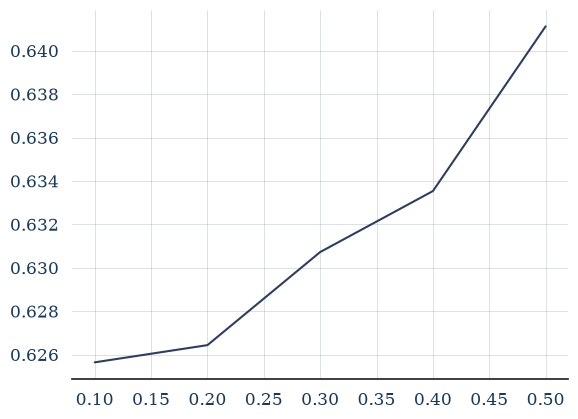

In [20]:
plt.plot(levels, accuracy)

### more tests?


## Test only